Fig5B



Processing Sample phase...

Processing Delay phase...


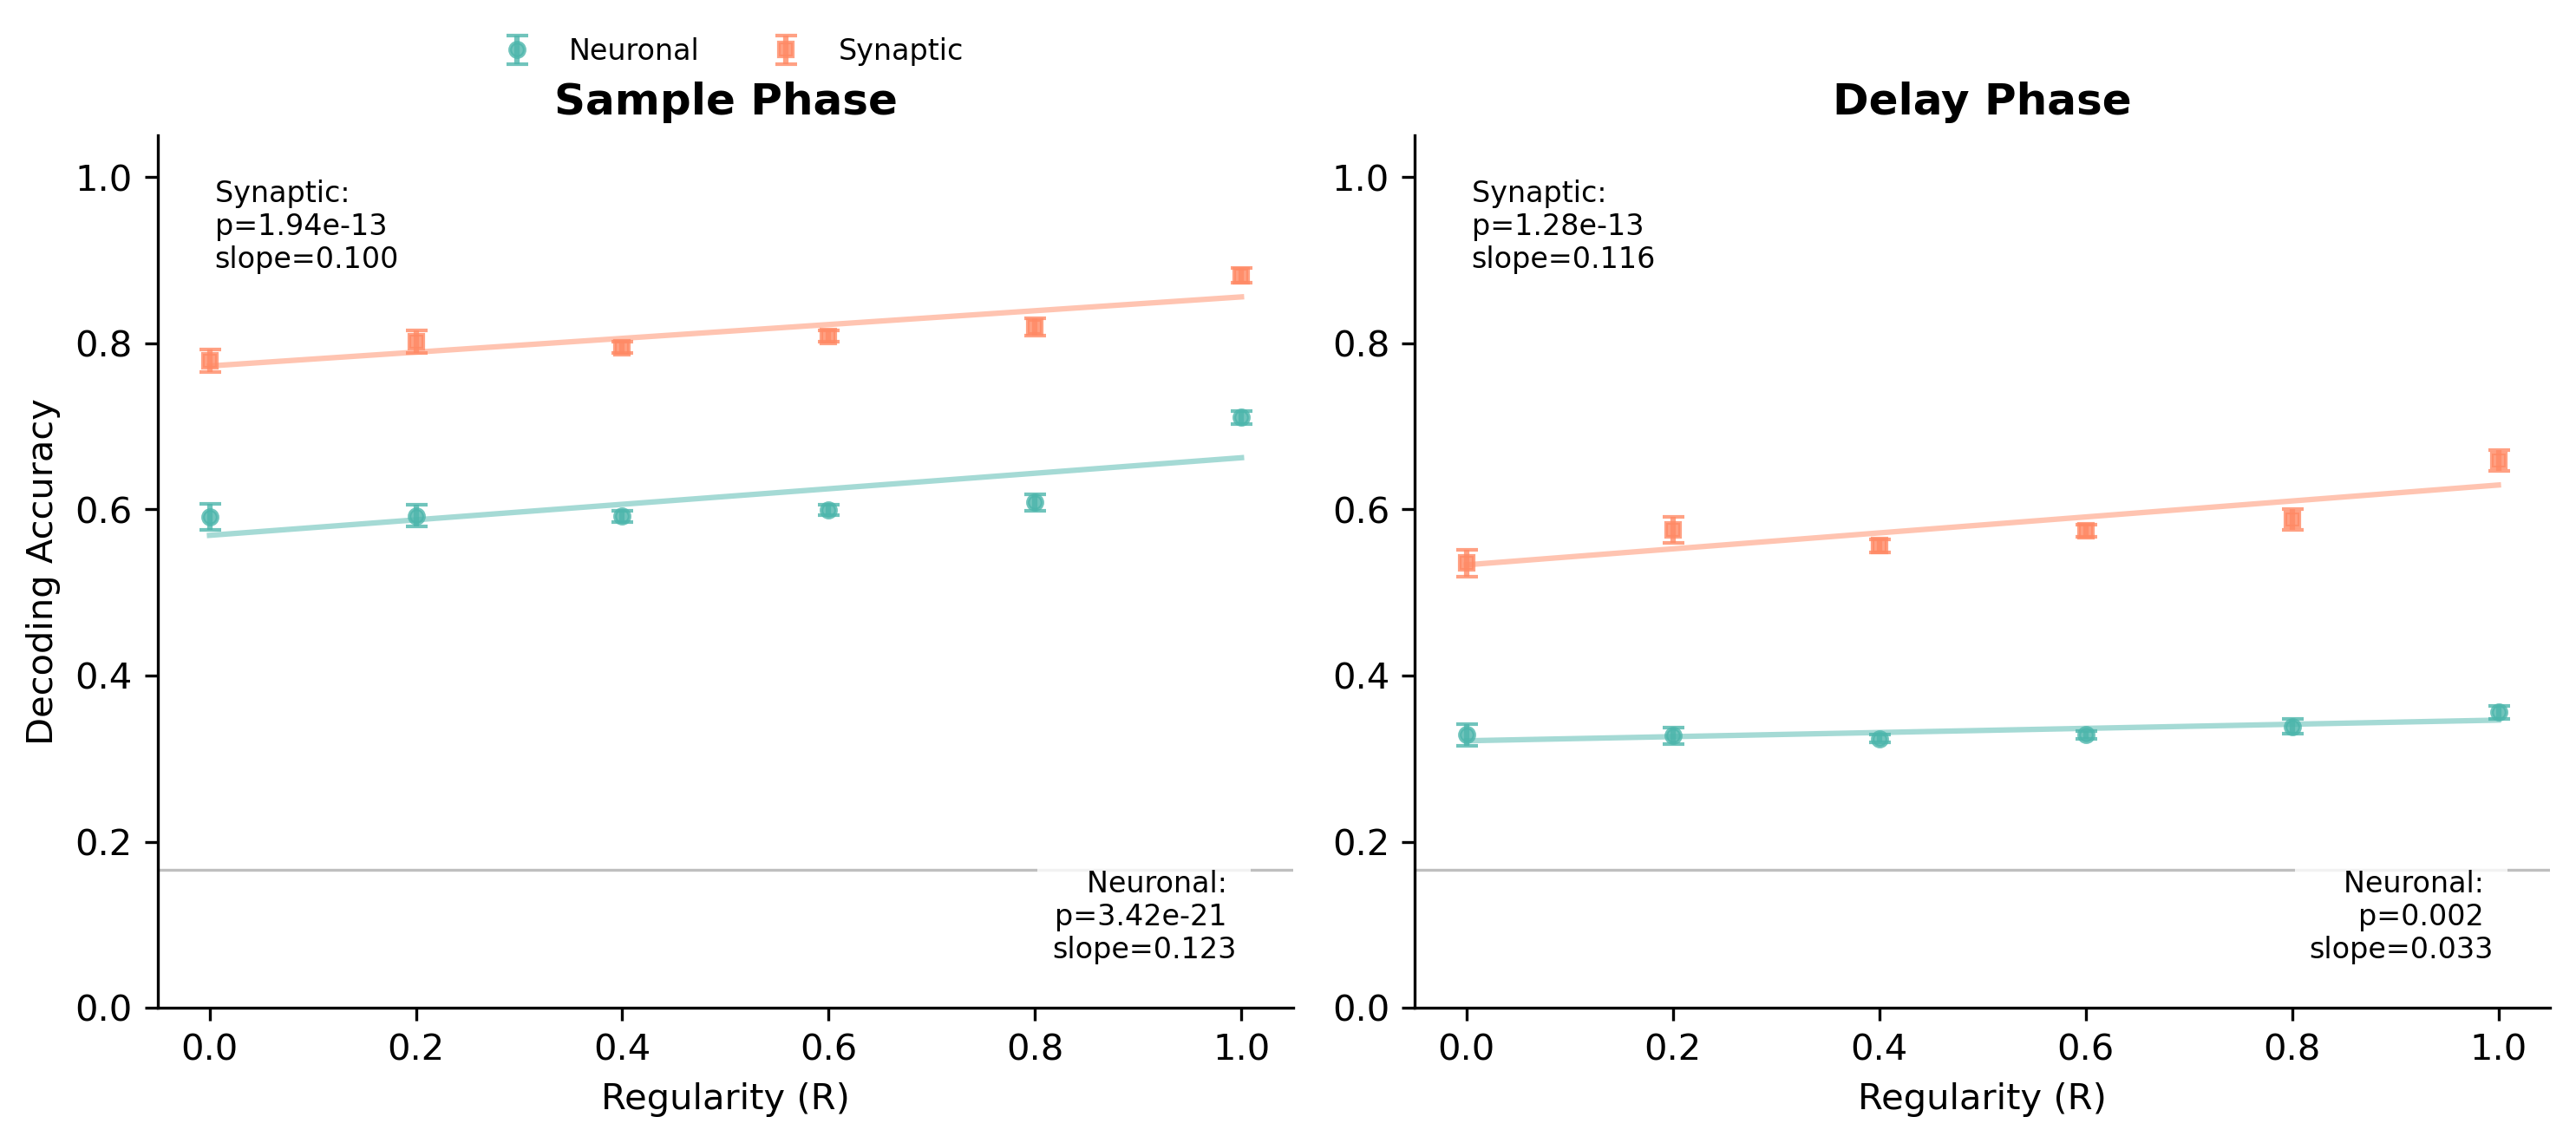

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import ttest_rel, pearsonr, linregress
import warnings

warnings.filterwarnings('ignore')

target_dirs = [
    '100-250', '100-300', '100-350', '100-400', '100-450', '100-500',
    '120-300', '120-350', '120-400', '120-450', '120-500',
    '140-350', '140-400', '140-450', '140-500'
]


def linear_func(x, a, b):
    return a * x + b

def parse_dir_name(dir_name):
    parts = dir_name.split('-')
    sd = int(parts[0])//10
    ioi = int(parts[1])//10
    return sd, ioi

def collect_flat_data(phase='sample'):
    conditions_map = {'rhy': ['rhy_ch0', 'rhy_ch3'], 'arrhy': ['arrhy_ch0', 'arrhy_ch3']}
    data_list = []
    
    for dir_name in target_dirs:
        sd, ioi = parse_dir_name(dir_name)
        results_dir = os.path.join(dir_name, "results_by_R_bin")
        if not os.path.exists(results_dir): continue
        
        for cond_type in ['rhy', 'arrhy']:
            for cond in conditions_map[cond_type]:
                result_file = os.path.join(results_dir, f"{cond}_R_binned_results.npz")
                if not os.path.exists(result_file): continue
                
                try:
                    data = np.load(result_file, allow_pickle=True)
                    results_by_bin = data['results_by_bin'].item()
                except: continue
                
                for bin_idx in results_by_bin:
                    bin_info = results_by_bin[bin_idx]
                    R_val = bin_info['R_mean']
                    acc_neu_matrix = bin_info['acc_neuronal']
                    acc_syn_matrix = bin_info['acc_synaptic']
                    
                    for pos in range(6):
                        if phase == 'Sample':
                            t_start = int(50 + pos * ioi)
                            t_end = int(t_start + ioi * 5 + sd)
                        else: # delay
                            sample_end = int(50 + pos * ioi + ioi * 5 + sd)
                            t_start = sample_end 
                            t_end = int(t_start + 100)
                        
                        t_end_adj = min(t_end, acc_neu_matrix.shape[0])
                        if t_start < t_end_adj:
                            acc_neu = acc_neu_matrix[t_start:t_end_adj, pos].mean()
                            acc_syn = acc_syn_matrix[t_start:t_end_adj, pos].mean()
                            data_list.append({'R_raw': R_val, 'acc_neu': acc_neu, 'acc_syn': acc_syn})
    return pd.DataFrame(data_list)

def process_and_plot(phase, ax):
    print(f"\nProcessing {phase} phase...")
    df = collect_flat_data(phase)
    
    # 1. MinMax Normalization
    min_r, max_r = df['R_raw'].min(), df['R_raw'].max()
    df['R_norm'] = (df['R_raw'] - min_r) / (max_r - min_r)
    
    # 2. Binning
    bins = [0, 0.05, 0.2, 0.4, 0.6, 0.8, 1.01]
    labels = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    df['bin'] = pd.cut(df['R_norm'], bins=bins, labels=labels, include_lowest=True)

    # Raw points for statistics (pre-binning)
    neu_raw = df[['R_norm', 'acc_neu']].dropna()
    syn_raw = df[['R_norm', 'acc_syn']].dropna()
    
    # 3. Aggregate (for plotting only)
    summary = df.groupby('bin')[['acc_neu', 'acc_syn']].agg(['mean', 'sem', 'count'])
    x = np.array(labels)
    y_ne = summary['acc_neu']['mean'].values
    ye_ne = summary['acc_neu']['sem'].values
    y_sy = summary['acc_syn']['mean'].values
    ye_sy = summary['acc_syn']['sem'].values
    
    # 4. Statistical Tests (t-test between curves)
    p_values = []
    for b in labels:
        bin_subset = df[df['bin'] == b]
        if len(bin_subset) > 1:
            _, p_val = ttest_rel(bin_subset['acc_neu'], bin_subset['acc_syn'])
            p_values.append(p_val)
        else:
            p_values.append(np.nan)

    # 5. Plotting & Fitting
    colors = {'neu': '#4DB6AC', 'syn': '#FF8A65'}
    names = {'neu': 'Neuronal', 'syn': 'Synaptic'}
    
    # --- Neuronal ---
    ax.errorbar(x, y_ne, yerr=ye_ne, fmt='o', color=colors['neu'], capsize=3, label=names['neu'], alpha=0.8, markersize=4)
    
    # Fit Neuronal line from binned means, but stats from raw points
    if len(x) >= 2:
        popt, _ = curve_fit(linear_func, x, y_ne)
        x_fit = np.linspace(0, 1, 100)
        ax.plot(x_fit, linear_func(x_fit, *popt), color=colors['neu'], alpha=0.5)

        if len(neu_raw) >= 3:
            r_val, p_val = pearsonr(neu_raw['R_norm'], neu_raw['acc_neu'])
            slope_raw, _, _, _, _ = linregress(neu_raw['R_norm'], neu_raw['acc_neu'])
            p_str = f'{p_val:.2e}' if p_val < 0.001 else f'{p_val:.3f}'
            stats_text = f"Neuronal: \np={p_str} \nslope={slope_raw:.3f}"
            ax.text(0.95, 0.05, stats_text, transform=ax.transAxes, fontsize=8, 
                    color='black', va='bottom', ha='right', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # --- Synaptic ---
    ax.errorbar(x, y_sy, yerr=ye_sy, fmt='s', color=colors['syn'], capsize=3, label=names['syn'], alpha=0.8, markersize=4)
    
    # Fit Synaptic line from binned means, but stats from raw points
    if len(x) >= 2:
        popt, _ = curve_fit(linear_func, x, y_sy)
        x_fit = np.linspace(0, 1, 100)
        ax.plot(x_fit, linear_func(x_fit, *popt), '-', color=colors['syn'], alpha=0.5)

        if len(syn_raw) >= 3:
            r_val, p_val = pearsonr(syn_raw['R_norm'], syn_raw['acc_syn'])
            slope_raw, _, _, _, _ = linregress(syn_raw['R_norm'], syn_raw['acc_syn'])
            p_str = f'{p_val:.2e}' if p_val < 0.001 else f'{p_val:.3f}'
            stats_text = f"Synaptic: \np={p_str} \nslope={slope_raw:.3f}"
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=8, 
                    color='black', va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    # Significance Markers
    # for i, p in enumerate(p_values):
    #     if p < 0.05:
    #         sig_symbol = '***' if p < 0.001 else '**' if p < 0.01 else '*'
    #         max_y = max(y_ne[i] + ye_ne[i], y_sy[i] + ye_sy[i])
    #         ax.text(x[i], max_y + 0.02, sig_symbol, ha='center', fontsize=10, fontweight='bold')

    # Styles
    ax.set_title(f'{phase} Phase', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Regularity (R)')
    ax.set_xticks(labels)
    ax.set_xticklabels(['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'])
    ax.axhline(0.166, color='gray', linewidth=0.8, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    if phase == 'Sample':
        ax.set_ylabel('Decoding Accuracy')
        ax.legend(loc='lower center', fontsize=8, ncol=2, bbox_to_anchor=(0.5, 1.05), frameon=False)

# Main Execution
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), dpi=300)

process_and_plot('Sample', axes[0])
process_and_plot('Delay', axes[1])

plt.tight_layout()
plt.savefig('R_norm.pdf', format='pdf', bbox_inches='tight')
plt.show()